# Thermophysical Property: Melting Point

## The goal of this challenge is to predict the melting point in temperature units of Kelvin for organic compounds given molecular descriptors.

### We start installing the RDKIT, an open-source cheminformatics library used to convert molecular structures into numerical representations that machine learning models can understand.

In [10]:
%pip install rdkit


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import pandas as pd
import numpy as np

In [12]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

# Exploratory Analysis

In [13]:
# Checking null values
df_train.isnull().sum()

id           0
SMILES       0
Tm           0
Group 1      0
Group 2      0
            ..
Group 420    0
Group 421    0
Group 422    0
Group 423    0
Group 424    0
Length: 427, dtype: int64

In [14]:
# Checking duplicates
df_train.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2657    False
2658    False
2659    False
2660    False
2661    False
Length: 2662, dtype: bool

In [15]:
# Checking unique values
df_train['SMILES'].nunique()

2662

# Converting SMILES to Morgan Fingerprints (ECFP)
## Morgan fingerprints transform molecular structures into numerical vectors that capture structural patterns at different scales

In [16]:
def smiles_to_morgan_bits(smiles: str, radius=2, n_bits=2048):
  mol = Chem.MolFromSmiles(smiles)
  if mol is None:
      return None
  generator = GetMorganGenerator(radius=radius, fpSize=n_bits)
  fp = generator.GetFingerprint(mol)

  # Convert the fingerprint in an array 0/1
  arr = np.zeros((n_bits,), dtype=int)
  fp_bits = list(fp.GetOnBits())
  arr[fp_bits] = 1
  return arr


In [17]:
# Applying in the dataset
fps = df_train["SMILES"].apply(smiles_to_morgan_bits)
mask_valid = fps.notna()

In [18]:
X_fp = np.vstack(fps[mask_valid].values)

descrip_cols = [c for c in df_train.columns if c.startswith("Group")]
X_desc = df_train.loc[mask_valid, descrip_cols].to_numpy()

In [19]:
y = df_train.loc[mask_valid, "Tm"].to_numpy().astype(float)

In [20]:
X = np.hstack([X_fp, X_desc])
X[0:10]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(10, 2472))

# Regressor Tree Decision

In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating a tree object
dt_regressor = DecisionTreeRegressor(random_state=42)

In [22]:
dt_regressor.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [23]:
y_pred = dt_regressor.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # raiz do MSE
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae}")
print(f"MSE : {mse}")
print(f"RMSE: {rmse}")
print(f"R^2 : {r2}")

MAE : 40.72500938086304
MSE : 3723.457854596622
RMSE: 61.02014302340353
R^2 : 0.5033581005912706


Current RMSE: 61.02

## Cross-Validation and Hyper-parameters

In [25]:
from sklearn.model_selection import KFold, GridSearchCV

cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Creating a GridSearchCV object
grid_search = GridSearchCV(estimator=dt_regressor, param_grid=param_grid,
                           cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)

# Fitting the grid search to the data
grid_search.fit(X_train, y_train)

# Getting the best parameters and best score
best_params = grid_search.best_params_
best_score = np.sqrt(-grid_search.best_score_) # RMSE

print(f"Best Parameters: {best_params}")
print(f"Best RMSE: {best_score}")

Best Parameters: {'max_depth': 30, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best RMSE: 60.26549471173194


### Cross-Validation reduced RMSE in approximately 1 unit

# Random Forest

In [26]:
from sklearn.ensemble import RandomForestRegressor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regr = RandomForestRegressor(n_estimators=100, random_state=42)

In [27]:
regr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
y_pred = regr.predict(X_test)

In [29]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 50.74761184040073


New RMSE: 50.74

## Cross-Validation and Hyper-parameters

In [30]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestRegressor
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Create a GridSearchCV object for RandomForestRegressor
grid_search_rf = GridSearchCV(estimator=regr, param_grid=param_grid_rf,
                           cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to the training data
grid_search_rf.fit(X_train, y_train)

# Get the best parameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = np.sqrt(-grid_search_rf.best_score_)

print(f"Best Parameters (Random Forest): {best_params_rf}")
print(f"Best RMSE (Random Forest): {best_score_rf}")

Best Parameters (Random Forest): {'max_depth': 30, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RMSE (Random Forest): 50.980133765753294


Best RMSE: 50.98

# XGBoost

In [31]:
%pip install -q xgboost


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import xgboost as xgb

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
xgb_model = xgb.XGBRegressor (n_estimators=500, learning_rate=0.05, max_depth=8,
                        subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                        random_state=42)

In [34]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [35]:
y_pred = xgb_model.predict(X_test)

In [36]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 48.34131131859482


Current RMSE: 48.34

## Cross-Validation and Hyper-parameters

In [37]:
# DMatrix (faster/memory efficient)
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=None)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=None)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 8,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "alpha": 0.0,
    "random_state": 42,
    "tree_method": "hist",
    "device": "cuda"
}

In [38]:
cv = xgb.cv(params=params,dtrain=dtrain, num_boost_round=5000,
            nfold=5, early_stopping_rounds=100, stratified=False,
            seed=42, verbose_eval=100)

best_round = len(cv)
best_rmse_cv = cv["test-rmse-mean"].min()
print(f"Best CV RMSE: {best_rmse_cv:.4f} at round {best_round}")

/Users/gui/Desktop/Kaggle_MP/env/lib/python3.13/site-packages/xgboost/training.py:225: UserWarning: [10:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  return getattr(self.bst, name)(*args, **kwargs)
/Users/gui/Desktop/Kaggle_MP/env/lib/python3.13/site-packages/xgboost/training.py:231: UserWarning: [10:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.bst.update(self.dtrain, iteration, fobj)


[0]	train-rmse:82.20406+0.97799	test-rmse:82.63074+3.93848


/Users/gui/Desktop/Kaggle_MP/env/lib/python3.13/site-packages/xgboost/training.py:231: UserWarning: [10:46:29] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.bst.update(self.dtrain, iteration, fobj)


[100]	train-rmse:30.54589+0.60231	test-rmse:50.76856+2.30842
[200]	train-rmse:23.95379+0.55147	test-rmse:48.93149+2.42455
[300]	train-rmse:20.38383+0.61791	test-rmse:48.24043+2.48621
[400]	train-rmse:17.97507+0.58494	test-rmse:48.06386+2.52545
[500]	train-rmse:16.08842+0.58298	test-rmse:47.97101+2.57999
[600]	train-rmse:14.61076+0.56365	test-rmse:47.95780+2.60298
[700]	train-rmse:13.38645+0.52794	test-rmse:47.92874+2.59459
[788]	train-rmse:12.43700+0.51451	test-rmse:47.94669+2.58569
Best CV RMSE: 47.9145 at round 689


In [39]:
final_model = xgb.XGBRegressor(
    n_estimators=best_round,
    learning_rate=params["eta"],
    max_depth=params["max_depth"],
    subsample=params["subsample"],
    colsample_bytree=params["colsample_bytree"],
    reg_lambda=params["lambda"],
    reg_alpha=params["alpha"],
    objective=params["objective"],
    random_state=params["random_state"],
    tree_method="hist",
    device="cuda",
    n_jobs=-1
)

final_model.fit(X_train, y_train)

/Users/gui/Desktop/Kaggle_MP/env/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [10:47:01] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [40]:
y_pred = final_model.predict(X_test)

In [41]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 48.263641159561885


New RMSE: 48.26

# Checking if "Tm" is assymetric

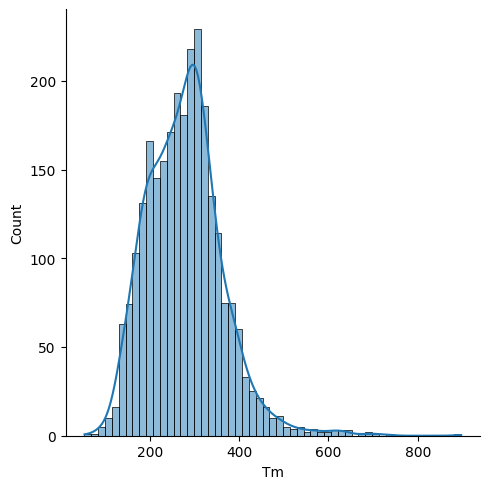

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creating an Histogram
sns.displot(data=df_train, x="Tm", kind="hist", kde=True)
plt.show()

The melting point distribution is right-skewed, with a long tail of high values, which increases sensitivity to large errors and makes further performance improvements more challenging.


## It's worth transforming the target applying a logarithm

In [43]:
# y

In [44]:
y_log = np.log1p(y)
# y_log

## Splitting the transformed data

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

In [46]:
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                        subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                        random_state=42
)

In [47]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Making predictions and reverting to the original space

In [48]:
y_pred_log = xgb_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [49]:
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.3f}")

RMSE: 49.278


# It seems we reachead a plateau of 48 for the root mean squared error. We should think now in matters of other Feature Engineering tactics

# Attempting multiple fingerprints

In [50]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator # Import GetMorganGenerator
from rdkit.Chem.AllChem import GetMACCSKeysFingerprint # Import GetMACCSKeysFingerprint from AllChem

def smiles_to_multiple_fingerprints(smiles: str, radius1=2, n_bits1=2048, radius2=3, n_bits2=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Generate Morgan Fingerprint with radius 2 using MorganGenerator
    generator1 = GetMorganGenerator(radius=radius1, fpSize=n_bits1)
    fp1 = generator1.GetFingerprint(mol)
    arr1 = np.zeros((n_bits1,), dtype=int)
    arr1[list(fp1.GetOnBits())] = 1

    # Generate Morgan Fingerprint with radius 3 using MorganGenerator
    generator2 = GetMorganGenerator(radius=radius2, fpSize=n_bits2)
    fp2 = generator2.GetFingerprint(mol)
    arr2 = np.zeros((n_bits2,), dtype=int)
    arr2[list(fp2.GetOnBits())] = 1


    # Generate MACCS keys fingerprint
    maccs = GetMACCSKeysFingerprint(mol)
    arr_maccs = np.zeros((167,), dtype=int) # MACCS keys have 167 bits
    arr_maccs[list(maccs.GetOnBits())] = 1


    return np.concatenate([arr1, arr2, arr_maccs])

# Apply the function to generate combined fingerprints
fps_combined = df_train["SMILES"].apply(smiles_to_multiple_fingerprints)
mask_valid_combined = fps_combined.notna()

# Stack the combined fingerprints and add descriptors
X_fp_combined = np.vstack(fps_combined[mask_valid_combined].values)
descrip_cols = [c for c in df_train.columns if c.startswith("Group")]
X_desc_combined = df_train.loc[mask_valid_combined, descrip_cols].to_numpy()

X_final = np.hstack([X_fp_combined, X_desc_combined])

# Update the target variable based on the valid mask
y_final = df_train.loc[mask_valid_combined, "Tm"].to_numpy().astype(float)

print("Shape of X_final:", X_final.shape)
print("Shape of y_final:", y_final.shape)

Shape of X_final: (2662, 4687)
Shape of y_final: (2662,)


In [51]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Split the data using the combined features and the original target variable
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Initialize and train the XGBoost Regressor model
xgb_model_final = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                                 subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                 random_state=42)

xgb_model_final.fit(X_train_final, y_train_final)

# Make predictions on the test set
y_pred_final = xgb_model_final.predict(X_test_final)

# Evaluate the model using RMSE
mse_final = mean_squared_error(y_test_final, y_pred_final)
rmse_final = np.sqrt(mse_final)

print(f"RMSE with combined fingerprints and descriptors: {rmse_final:.3f}")

RMSE with combined fingerprints and descriptors: 45.700


New RMSE: 45.70

## Finding the best number of estimators

In [52]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

X = X_final.astype(np.float32)
y = y_final.astype(np.float32)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmses = []
best_iters = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):
    print(f"Fold {fold}...")

    dtrain = xgb.DMatrix(X[tr_idx], label=y[tr_idx])
    dvalid = xgb.DMatrix(X[va_idx], label=y[va_idx])

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "max_depth": 8,
        "eta": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "nthread": -1,
        "seed": 42,
    }

    evals = [(dtrain, "train"), (dvalid, "valid")]

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=10000,
        evals=evals,
        early_stopping_rounds=200,
        verbose_eval=False,
    )

    best_iter = model.best_iteration
    best_rmse = model.best_score

    y_hat = model.predict(dvalid, iteration_range=(0, best_iter + 1))
    mse = mean_squared_error(y[va_idx], y_hat)
    rmse = np.sqrt(mse)

    rmses.append(rmse)
    best_iters.append(best_iter)


    print(f"  Fold {fold}: RMSE = {rmse:.3f} | best_iter = {best_iter}")

print("\nCV RMSE: {:.3f} ± {:.3f}".format(np.mean(rmses), np.std(rmses)))
print("best_iter (min/med/mean/max):",
      int(np.min(best_iters)), int(np.median(best_iters)),
      f"{np.mean(best_iters):.0f}", int(np.max(best_iters)))




Fold 1...
  Fold 1: RMSE = 44.768 | best_iter = 659
Fold 2...
  Fold 2: RMSE = 40.877 | best_iter = 1077
Fold 3...
  Fold 3: RMSE = 48.084 | best_iter = 68
Fold 4...
  Fold 4: RMSE = 42.580 | best_iter = 593
Fold 5...
  Fold 5: RMSE = 46.384 | best_iter = 1173

CV RMSE: 44.539 ± 2.579
best_iter (min/med/mean/max): 68 659 714 1173


The number of estimators for XGBoost was selected using 5-fold cross-validation with early stopping.

For each fold, training was stopped when the validation RMSE no longer improved, resulting in different optimal numbers of trees across folds.

To obtain a robust configuration that generalizes well across different data splits, the median of the optimal number of estimators (~700) was selected for the final model.

# Adding classic RDKit descriptors to the we ones currently have (ECFP4 + ECFP6 + MACCS + Group*)

In [53]:
from rdkit.Chem import Descriptors, rdMolDescriptors

def rdkit_desc_from_smiles(smiles: str):
  m = Chem.MolFromSmiles(smiles)
  if m is None:
    return None
  return {
      "MolWt": Descriptors.MolWt(m),
      "LogP": Descriptors.MolLogP(m),
      "TPSA": rdMolDescriptors.CalcTPSA(m),
      "HBD": rdMolDescriptors.CalcNumHBD(m),
      "HBA": rdMolDescriptors.CalcNumHBA(m),
      "RotB": rdMolDescriptors.CalcNumRotatableBonds(m),
      "RingCount": rdMolDescriptors.CalcNumRings(m),
      "HeavyAtom": Descriptors.HeavyAtomCount(m),
      "FracCSP3": rdMolDescriptors.CalcFractionCSP3(m),
  }

desc_series = df_train["SMILES"].apply(rdkit_desc_from_smiles)
mask_desc = desc_series.notna()
desc_df = pd.DataFrame(desc_series[mask_desc].tolist(),
                       index=df_train.index[mask_desc]).astype("float32")

# transform the fingerprints into a dataframe with the same index
# (X_fp_combined corresponds to the df_train[maks_valid_combined] lines)
fp_cols = [ f"fp_{i}" for i in range(X_fp_combined.shape[1])]
df_fp =pd.DataFrame(X_fp_combined, index=df_train.index[mask_valid_combined],
                    columns=fp_cols).astype("float32")

# getting the Groups* in the same schema
df_group = df_train.loc[mask_valid_combined, descrip_cols].astype("float32").fillna(0)

# joining everything by index
features_df = pd.concat([df_fp, df_group, desc_df], axis=1, join="inner").fillna(0)

# target aligned to the features
y_aligned = df_train.loc[features_df.index, "Tm"].astype("float32").to_numpy()
X_aligned = features_df.to_numpy(dtype="float32")

print("X_aligned:", X_aligned.shape, "| y_aligned:", y_aligned.shape)

X_aligned: (2662, 4696) | y_aligned: (2662,)


At this stage, each molecule is represented as a single numerical vector obtained by concatenating:
- Morgan fingerprints (radius 2 and 3),
- MACCS keys,
- RDKit physicochemical descriptors,
- and the original Group* features.

This final matrix (`X_aligned`) is the input used by all machine learning models.

In [54]:
from sklearn.metrics import mean_absolute_error, r2_score

X_tr, X_te, y_tr, y_te = train_test_split(X_aligned, y_aligned, test_size=0.2, random_state=42)

xgb_final = xgb.XGBRegressor(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    eval_metric="rmse"
)
xgb_final.fit(X_tr, y_tr)

pred = xgb_final.predict(X_te)
mae = mean_absolute_error(y_te, pred)
mse = mean_squared_error(y_te, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_te, pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R^2 : {r2:.4f}")

MAE : 28.672
RMSE : 43.889
R^2 : 0.7431


New RMSE: 43.89

# Trying XGB + Random Forest

In [55]:
from sklearn.ensemble import RandomForestRegressor

X_tr, X_te, y_tr, y_te = train_test_split(X_aligned, y_aligned, test_size=0.2, random_state=42)

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    eval_metric="rmse"
)
xgb_model.fit(X_tr, y_tr)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=800,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_tr, y_tr)


pred_xgb = xgb_model.predict(X_te)
pred_rf = rf_model.predict(X_te)

# Pondered mean
y_pred_ensemble = 0.6 * pred_xgb + 0.4 * pred_rf


mae = mean_absolute_error(y_te, y_pred_ensemble)
mse = mean_squared_error(y_te, y_pred_ensemble)
rmse = np.sqrt(mse)
r2 = r2_score(y_te, y_pred_ensemble)

print(f"MAE : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R^2 : {r2:.4f}")


MAE : 29.046
RMSE : 44.079
R^2 : 0.7408


In [56]:
for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
  y_pred_mix = w * pred_xgb + (1-w) * pred_rf
  mse_mix = mean_squared_error(y_te, y_pred_mix)
  rmse_mix = np.sqrt(mse_mix)
  print(f"Weight XGB={w:.1f} | RMSE={rmse_mix:.3f}")

Weight XGB=0.3 | RMSE=45.093
Weight XGB=0.4 | RMSE=44.675
Weight XGB=0.5 | RMSE=44.336
Weight XGB=0.6 | RMSE=44.079
Weight XGB=0.7 | RMSE=43.905


# XGB + Random Forest is not giving any additional improvement
## A simple feed-forward neural network was also tested, but it underperformed tree-based models on this tabular dataset and was therefore not pursued further.

### Key takeaways
- Feature engineering had a larger impact on performance than model complexity.
- Tree-based models outperformed neural networks on this structured dataset.
- Cross-validation and early stopping were essential to avoid overfitting.
- The lowest RMSE achieved was 43.89